In [2]:
import pandas as pd
import csv 

df = pd.read_csv('train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print(df.shape)
df.info()
df.isnull().sum().sort_values(ascending=False).head(10)

(1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 1

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64

In [ ]:
#cleaning 
df = df.drop(columns = ['Alley', 'PoolQC', 'MiscFeature', 'Fence'])

# Fill categorical features (text columns) with "None"
df["MasVnrType"].fillna("None", inplace=True)
df["FireplaceQu"].fillna("None", inplace=True)
df["GarageQual"].fillna("None", inplace=True)
df["GarageType"].fillna("None", inplace=True)

# Fill numerical features with 0
df["MasVnrArea"].fillna(0, inplace=True)
df["GarageYrBlt"].fillna(0, inplace=True)

# Fill LotFrontage with the median (a more realistic number)
df["LotFrontage"].fillna(df["LotFrontage"].median(), inplace=True)


garage_text_cols = ["GarageCond", "GarageFinish", "GarageQual", "GarageType"]
for col in garage_text_cols:
    if col in df.columns:  # check in case some were already dropped
        df[col].fillna("None", inplace=True)

# Numeric garage year
df["GarageYrBlt"].fillna(0, inplace=True)

df["Electrical"].fillna(df["Electrical"].mode()[0], inplace=True)

bsmt_cols = ["BsmtFinType1", "BsmtFinType2", "BsmtCond", "BsmtQual", "BsmtExposure"]
for col in bsmt_cols:
    df[col].fillna("None", inplace=True)



In [ ]:
df.info()

In [19]:
# Automatically find all object-type columns
cat_cols = df.select_dtypes(include=["object"]).columns

# Apply one-hot encoding to all of them
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)


In [24]:
# data splitting
y = df["SalePrice"]
x = df.drop(columns = ["SalePrice", "Id"])

from sklearn.model_selection import train_test_split

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
#check

from sklearn.metrics import mean_absolute_error

# Predict on test set
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")


RMSE: 52496.146902997585
MAE: 20652.167458697055
RMSE: 52496.146902997585


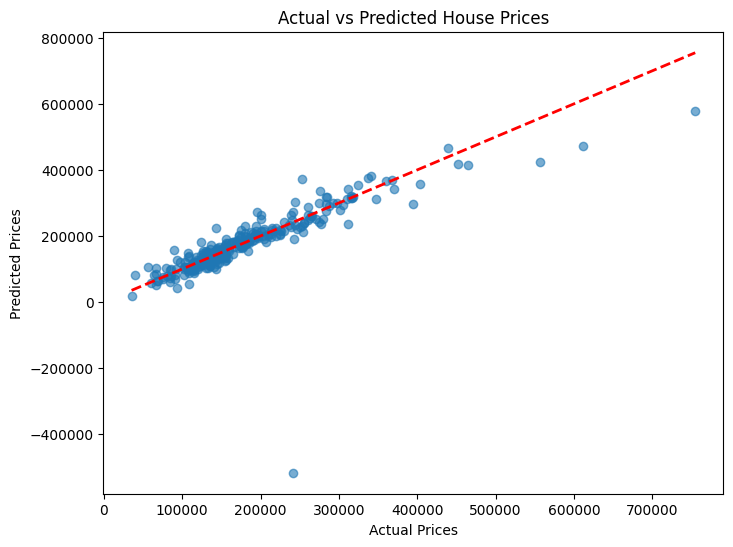

In [28]:
#plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()


In [29]:
#random forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Initialize the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest MAE: {mae_rf}")
print(f"Random Forest RMSE: {rmse_rf}")


Random Forest MAE: 17526.23205479452
Random Forest RMSE: 28641.907177603764


In [30]:
#xgboost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"XGBoost MAE: {mae_xgb}")
print(f"XGBoost RMSE: {rmse_xgb}")


XGBoost MAE: 16594.103515625
XGBoost RMSE: 26152.876094227187


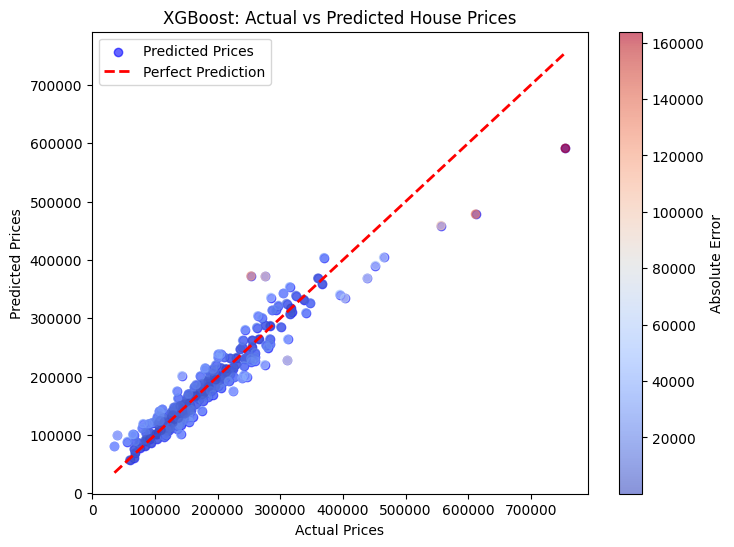

In [32]:
# Scatter plot of actual vs predicted prices
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.6, color='blue', label='Predicted Prices')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("XGBoost: Actual vs Predicted House Prices")
errors = np.abs(y_test - y_pred_xgb)
plt.scatter(y_test, y_pred_xgb, c=errors, cmap='coolwarm', alpha=0.6)
plt.colorbar(label='Absolute Error')
plt.legend()
plt.show()

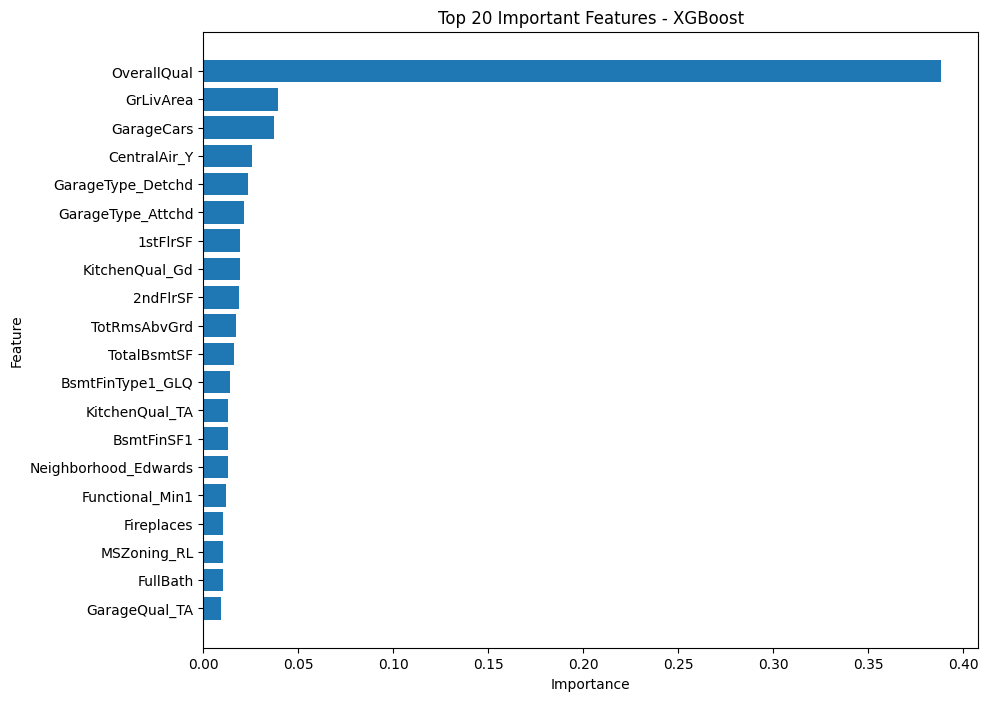

In [34]:
importance = xgb_model.feature_importances_

# Convert to a DataFrame for easier handling
feature_importance_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importance
})

# Sort by importance descending
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,8))
plt.barh(feature_importance_df['Feature'][:20][::-1], feature_importance_df['Importance'][:20][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Important Features - XGBoost")
plt.show()


In [35]:
#feature engineering

df["TotalBathrooms"] = (
    df["FullBath"] + 0.5*df["HalfBath"] +
    df["BsmtFullBath"] + 0.5*df["BsmtHalfBath"]
)

df["TotalSF"] = df["GrLivArea"] + df["TotalBsmtSF"]

df["TotalPorchSF"] = (
    df["OpenPorchSF"] + df["EnclosedPorch"] +
    df["3SsnPorch"] + df["ScreenPorch"]
)

X = df.drop(columns=["SalePrice", "Id", "FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath", "GrLivArea", "TotalBsmtSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch"])
y = df["SalePrice"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"XGBoost MAE (engineered features): {mae_xgb}")
print(f"XGBoost RMSE (engineered features): {rmse_xgb}")

XGBoost MAE (engineered features): 16065.595703125
XGBoost RMSE (engineered features): 26490.519964696803


In [36]:
#further tuning
from sklearn.model_selection import GridSearchCV
xgb = XGBRegressor(random_state=42)

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 0.9, 1],
    'colsample_bytree': [0.7, 0.9, 1]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best MAE (CV):", -grid_search.best_score_)



best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print(f"Tuned XGBoost MAE: {mae_best}")
print(f"Tuned XGBoost RMSE: {rmse_best}")



Fitting 3 folds for each of 162 candidates, totalling 486 fits
Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.9}
Best MAE (CV): 15070.6513671875
Tuned XGBoost MAE: 16131.9248046875
Tuned XGBoost RMSE: 25864.893272542224


'2.20.0'